## [Luis Alejandro Rodríguez Arenas](https://luigitoby.github.io/)
## Cod. 202321287
# Taller 6

# Librerías

In [127]:
from sympy import symbols, Matrix, pi, cos, sin, simplify, eye, solve, latex, atan2, pprint, init_printing, Derivative, sqrt, diff, Eq, tan, integrate, lambdify
from sympy.physics.vector import dynamicsymbols, init_vprinting, ReferenceFrame, cross, Point, dot
from numpy import deg2rad, linspace, gradient
import numpy as np
import matplotlib.pyplot as plt
init_vprinting(use_latex='mathjax')
import scipy as sp

# ej1 
La barra uniforme de masa m y largo L con pequeños rodillos en los extremos, se libera
desde el reposo en la posición mostrada.
a. Determinar la fuerza normal a la superficie.
b. Determinar la aceleración angular inicial después de liberar la barra del reposo.

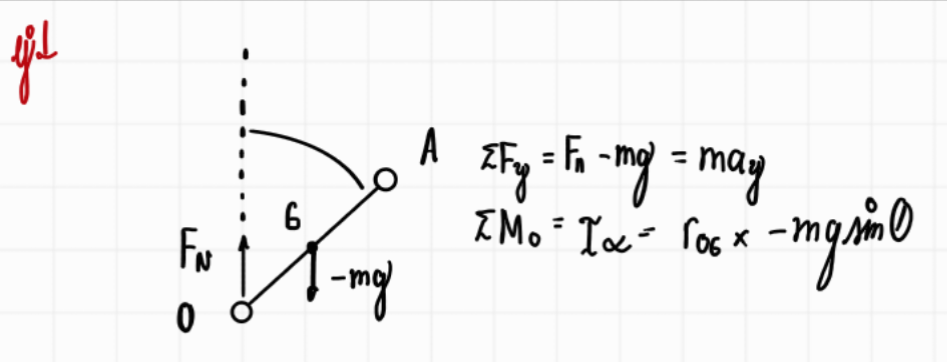

### parte a 

In [128]:
# Símbolos (theta depende del tiempo, thd = d theta / dt)
m, g, L, N, H, aAx = symbols('m g L N H aAx', positive=True, real=True)
theta, thd, thdd = symbols('theta thd thdd', real=True)  

# Momentos de inercia
I_G = m*L**2/12
I_A = m*L**2/3   # Ejes paralelos

# Fuerzas 
eq1 = Eq(N - m*g, -m*(L/2)*(thdd*sin(theta) + thd**2 * cos(theta)))
eq2 = Eq(H, m*( aAx + (L/2)*( cos(theta)*thdd - sin(theta)*thd**2 ) ))

# Momentos
eq3 = Eq(-m*g*(L/2)*sin(theta), I_A*thdd - m*(L/2)*cos(theta)*aAx)
eq4 = Eq(N*(L/2)*sin(theta), I_G*thdd)

# Solucionamos para todo
sol = solve([eq1, eq2, eq3, eq4], [N, H, aAx, thdd], dict=True, simplify=True)

# Simplificamos todo
sol_simpl = [{k: simplify(v) for k, v in s.items()} for s in sol]

# Ahora evaluamos en el instante de liberación: thd = 0 (velocidad angular inicial cero)
sol_release = [{k: v.subs(thd, 0) for k, v in s.items()} for s in sol_simpl]

N_final = simplify(sol_release[0][N])

N_final


     g⋅m     
─────────────
     2       
3⋅sin (θ) + 1

### parte b

In [129]:
# Símbolos (theta depende del tiempo, thd = d theta / dt)
m, g, L, N, H, aAx = symbols('m g L N H aAx', positive=True, real=True)
theta, thd, thdd = symbols('theta thd thdd', real=True)  

# Momentos de inercia
I_G = m*L**2/12
I_A = m*L**2/3   # Ejes paralelos

# Fuerzas 
eq1 = Eq(N - m*g, -m*(L/2)*(thdd*sin(theta) + thd**2 * cos(theta)))
eq2 = Eq(H, m*( aAx + (L/2)*( cos(theta)*thdd - sin(theta)*thd**2 ) ))

# Momentos
eq3 = Eq(-m*g*(L/2)*sin(theta), I_A*thdd - m*(L/2)*cos(theta)*aAx)
eq4 = Eq(N*(L/2)*sin(theta), I_G*thdd)

# Solucionamos para todo
sol = solve([eq1, eq2, eq3, eq4], [N, H, aAx, thdd], dict=True, simplify=True)

# Simplificamos todo
sol_simpl = [{k: simplify(v) for k, v in s.items()} for s in sol]

# Ahora evaluamos en el instante de liberación: thd = 0 (velocidad angular inicial cero)
sol_release = [{k: v.subs(thd, 0) for k, v in s.items()} for s in sol_simpl]

# Extraemos la aceleración angular inicial
thdd_final = simplify(sol_release[0][thdd])

thdd_final



   6⋅g⋅sin(θ)    
─────────────────
  ⎛     2       ⎞
L⋅⎝3⋅sin (θ) + 1⎠

# ej2
La barra uniforme AB está unida por un pin al deslizador A. El sistema se encontraba en
reposo en la posición 𝜃 = 0 antes de aplicar la fuerza de 12 N. Determinar la aceleración
del deslizador y la aceleración angular de la barra inmediatamente después de que la
fuerza de 12 N es aplicada

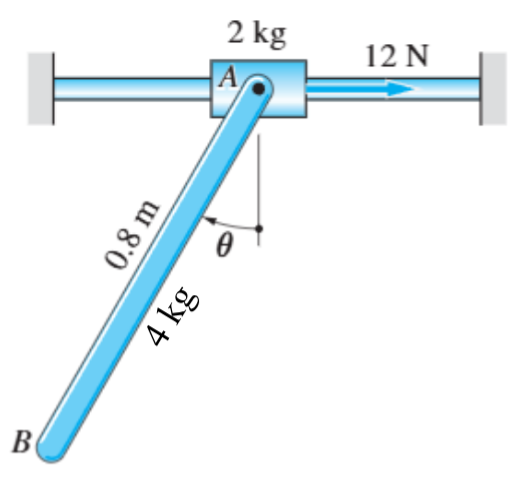

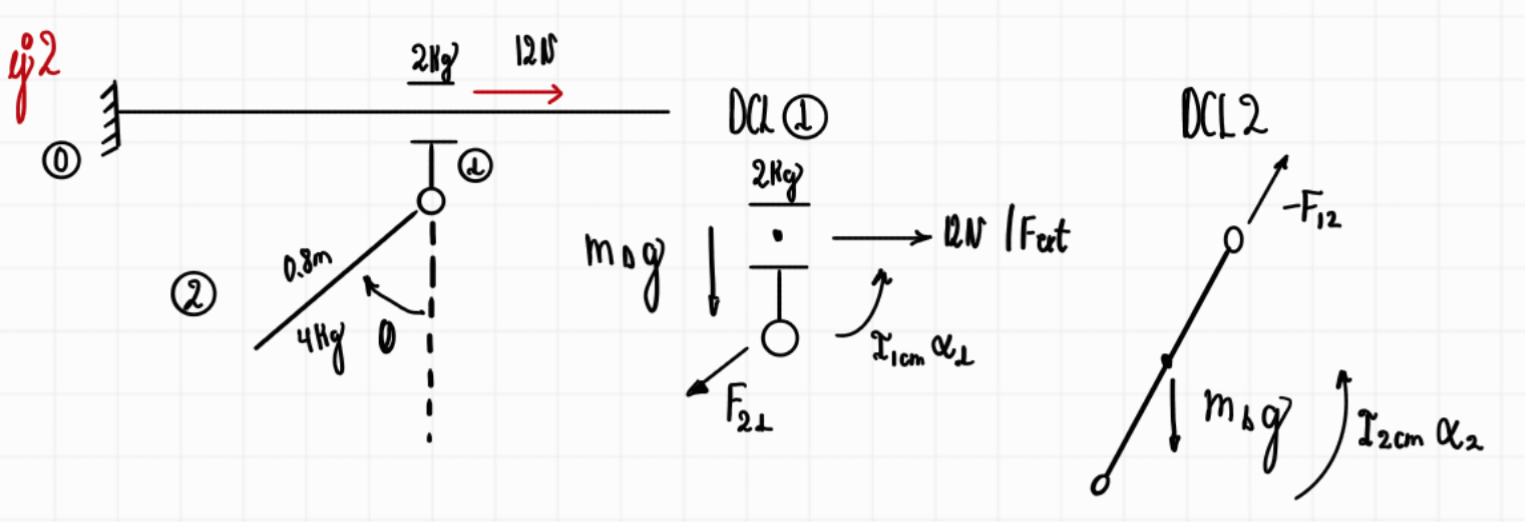

In [130]:
# Símbolos 
t = symbols('t')
m1, m2, L, g, Fe = symbols('m1 m2 L g Fe', positive=True)
F01y, F12x, F12y = symbols('F01y F12x F12y')
x, theta = dynamicsymbols('x theta')

# Marcos
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', [(pi/2) - theta, N.z])

# Inercia y cinemática
I2cm = m2*L**2/12
r_cm1 = x*N.x
r_cm2 = x*N.x - (L/2)*A.x
acm1 = r_cm1.diff(t, N).diff(t, N)
acm2 = r_cm2.diff(t, N).diff(t, N)

# Fuerzas
g_vec = -g*N.y
F01 = F01y*N.y
F12 = F12x*N.x + F12y*N.y
Fext = Fe*N.x

# Ecuaciones
sumF1 = F01 + m1*g_vec - F12 + Fext - m1*acm1
sumF2 = F12 + m2*g_vec - m2*acm2
sumM2 = (-L/2*A.x).cross(F12) - I2cm*theta.diff(t,2)*N.z

eqs = [
    sumF1.dot(N.x),
    sumF1.dot(N.y),
    sumF2.dot(N.x),
    sumF2.dot(N.y),
    sumM2.dot(N.z)
]

# Solución simbólica
sol = solve(eqs, [F01y, F12x, F12y, x.diff(t,2), theta.diff(t,2)], dict=True)[0]

# Sustitución numérica
vals = {m1: 2, m2: 4, L: 0.8, g: 9.81, Fe: 12, theta: 0}  # θ=0 justo al liberar
aA_expr = sol[x.diff(t,2)].subs(vals)
alpha_expr = sol[theta.diff(t,2)].subs(vals)

aA = float(aA_expr.evalf())
alpha = float(alpha_expr.evalf())

# Resultados
print(f"Aceleración del deslizador: {aA:.3f} m/s²")
print(f"Aceleración angular de la barra: {alpha:.3f} rad/s²")


Aceleración del deslizador: 4.000 m/s²
Aceleración angular de la barra: 7.500 rad/s²


### ej3
La barra uniforme AB está en reposo en la posición mostrada cuando de corta la cuerda
BD. Determinar la aceleración angular de la barra y la aceleración en el punto B
inmediatamente después de que se corta la unión BD


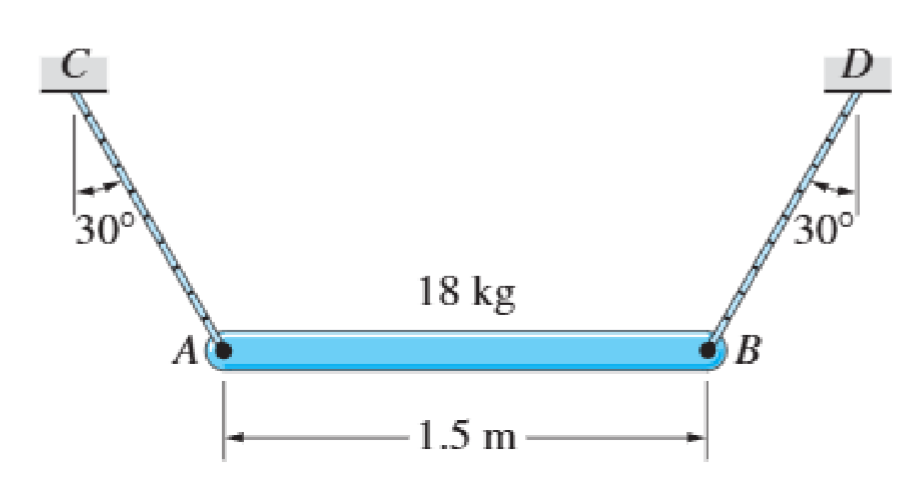


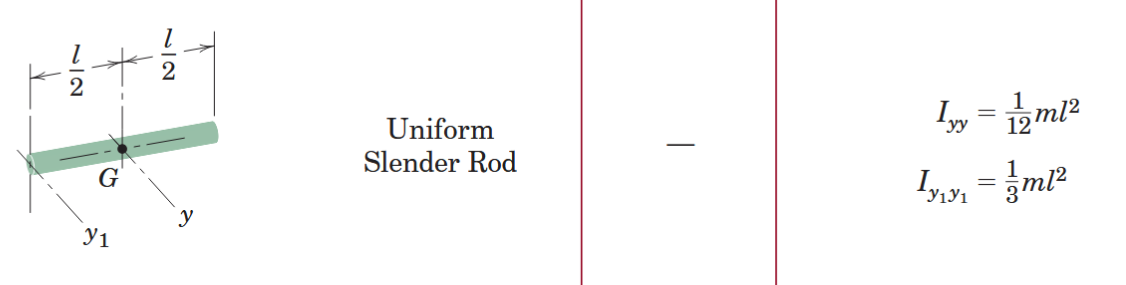


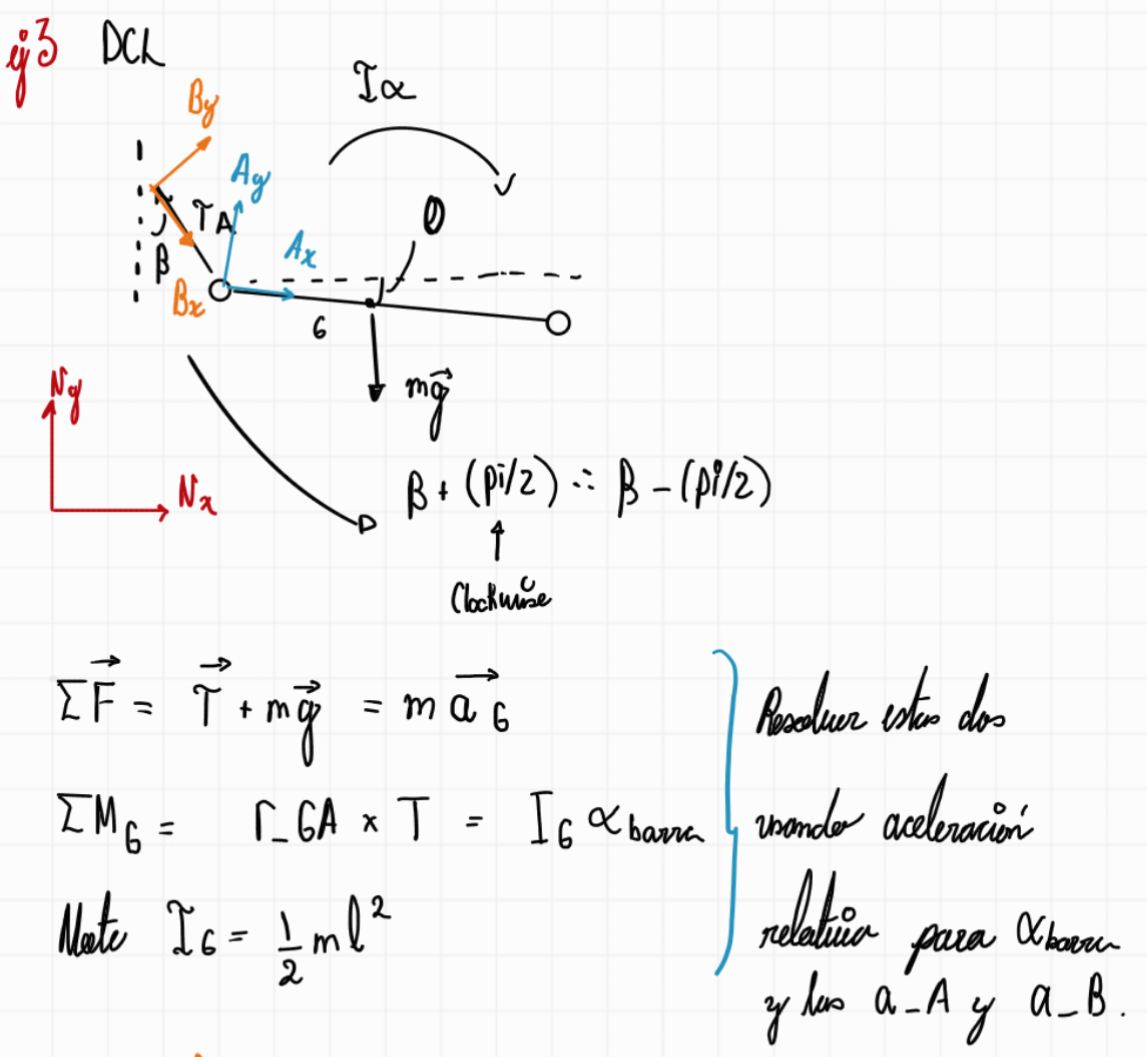

### A. Determinar la aceleración angular de la barra

In [131]:
T, m, l_b, g, a_Gy, a_Gx, a_y, a_x, a_B = symbols('T m l_b g a_Gy a_Gx a_y a_x a_B', real=True)
theta, beta = dynamicsymbols('theta beta')
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', [-theta, N.z]) # toca que sea negativo porque vamos en sentido horario
B = N.orientnew('B', 'Axis', [beta- (pi/2), N.z])

# def de vectores

TA = -T*B.x

a_cm = a_Gx*N.x + a_Gy*N.y

g_vect = -g*N.y
omega = -theta.diff(t)*N.z # Esta es la velocidad angular de la barra que concuerda con la derivada de theta, pero en sentido negativo pues va en direccion antihoraria.
alpha = -theta.diff(t,t)*N.z # Esta es la acc angular de la barra que concuerda con la derivada de theta, pero en sentido negativo pues va en direccion antihoraria.
Icm = (1/12)*m*l_b**2 # (momento de inercia de la barra respecto a su centro de masa)
IA = Icm + m*(l_b**2) # (momento de inercia de la barra respecto al punto A, teorema de ejes paralelos, pudimos tomar la que ya esta desde A, pero así es más general), además la otra no se porque no me hace correr el códigop
# También se puede usar la otra que es 1/3*m*l**2 pero no me corre con esa, creo que es por los vectores 

# Info geométrica
r_AG = l_b/2*A.x
r_GB = l_b/2*A.x

rAB = r_AG + r_GB

# Luego usamos aceleracion relativa para obtener la aceleración en A

a_A = -a_y*B.y - a_x*B.x # Note ambos son negativos por las direcciones del movimiento circular, pues va hacaia "adentro" de la cuerda y hacia la izquierda respectivamente.

a_G  = a_A + alpha.cross(r_AG) + omega.cross(omega.cross(r_AG))

# Ecuaciones de movimiento

sumF = TA + m*g_vect - m*a_G
sumM_g = -r_AG.cross(TA)-Icm*alpha
eqs = [
    sumF.dot(N.x),
    sumF.dot(N.y),
    sumM_g.dot(N.z)
]


sol = solve(eqs, (T, a_y, theta.diff(t,t))) # a_y en este caso es nuestra aceleración tangencial y es nuestra solución
display(sol)


alpha = sol[theta.diff(t,t)]*N.z

SUBS = {
    theta.diff(t): 0, 
    theta:0, beta: deg2rad(30), 
    m: 18, 
    l_b: 1.5, 
    a_x: 0, 
    g: 9.81
}

display((alpha.dot(N.z)).subs(SUBS).evalf())

⎧                                                           2                  ↪
⎪                                               2.0⋅aₓ⋅m⋅sin (β)               ↪
⎨T: ────────────────────────────────────────────────────────────────────────── ↪
⎪          2       2             2                                             ↪
⎩   6.0⋅sin (β)⋅sin (θ) + 2.0⋅sin (β) - 12.0⋅sin(β)⋅sin(θ)⋅cos(β)⋅cos(θ) + 6.0 ↪

↪                                                                              ↪
↪                                                                              ↪
↪ ────────────────────────────── + ─────────────────────────────────────────── ↪
↪     2       2             2             2       2             2              ↪
↪ ⋅cos (β)⋅cos (θ) + 2.0⋅cos (β)   6.0⋅sin (β)⋅sin (θ) + 2.0⋅sin (β) - 12.0⋅si ↪

↪              2                                                               ↪
↪  2.0⋅aₓ⋅m⋅cos (β)                                                            ↪
↪ ────────────────────────

9.05538461538462

### b. la aceleración en el punto B inmediatamente después de que se corta la unión BD

In [132]:
# Aceleración relativa de nuevo para obtener la aceleración en B
a_B = (alpha.cross(rAB) + omega.cross(omega.cross(rAB))).express(N).simplify()

display(a_B.subs(SUBS).evalf())


13.5830769230769 n_y

# ej4
El objeto en la figura se suelta desde el reposo en la posición mostrada. Considere que
el objeto tiene una masa m conocida.
a. Encontrar la aceleración inicial en el punto A.
b. Asumiendo los valores de 𝑚 = 3 𝑘𝑔 y 𝐿 = 2 𝑚, graficar la evolución del centro de
masa de la barra durante los primeros 3 segundos del movimiento

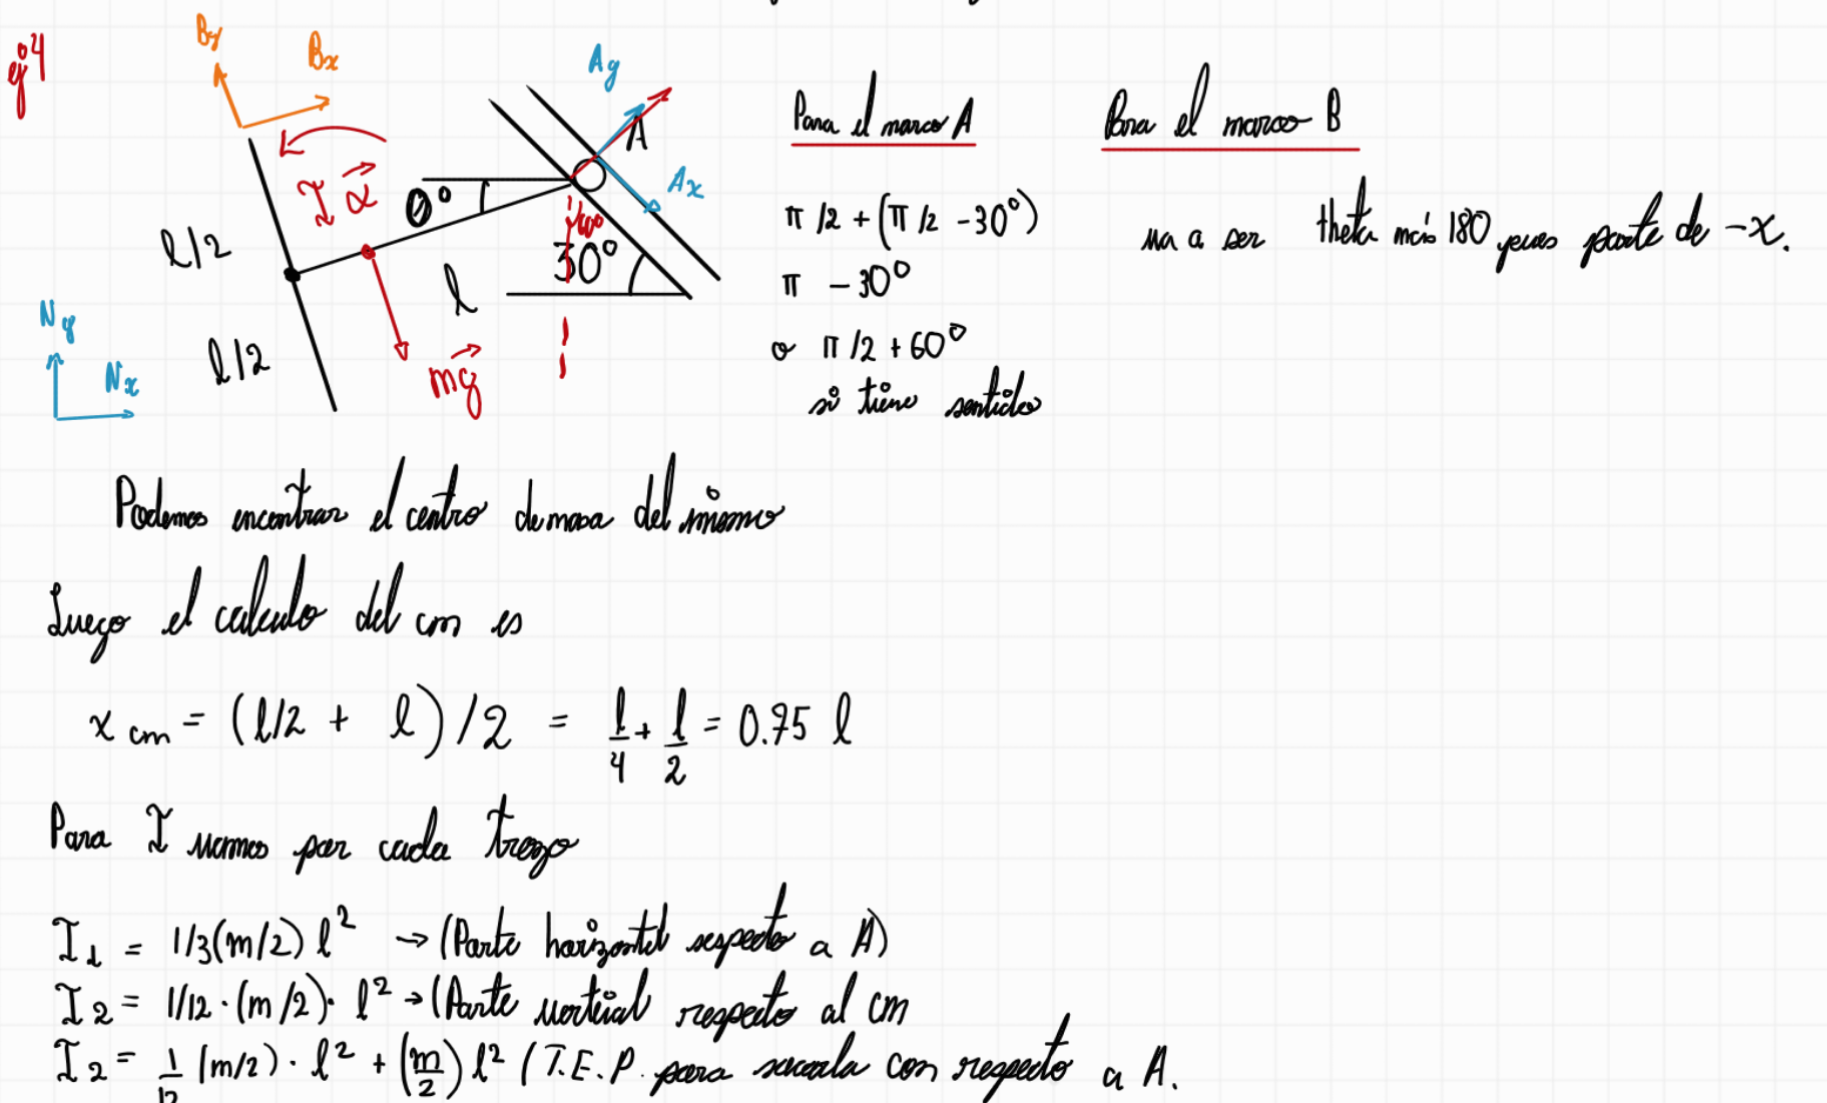

### a. Encontrar la aceleración inicial en el punto A.

In [133]:
l, beta, m, R, g = symbols('l beta m R g', positive=True, real=True)

N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', [-beta, N.z])     # rampa inclinada 30° hacia abajo
B = N.orientnew('B', 'Axis', [theta, N.z])     # barra parte horizontal (θ=0)


I = (1/3*(m/2)*l**2 + 1/12*(m/2)*l**2 + (m/2)*(l)**2).simplify()
cm = 0.75*l

# Sacamos el momento de inercia total respecto a A.

# Cinemática imaginemos un instante de tiempo donde ya se movvio A y detras hay un punto O de referencia, el punto G es el cm
r_OA = -x*A.x
a_OA = r_OA.diff(t,N).diff(t,N)

r_AG = cm*B.x
a_AG = r_AG.diff(t,N).diff(t,N)

r_OG = r_OA + r_AG

a_OG = r_OG.diff(t,N).diff(t,N)

# Dinámica
F01n = symbols('F_01n', real=True)
F01 = F01n*A.y  # normal de contacto, perpendicular a la rampa
g_vec = -g*N.y

alpha = theta.diff(t, t)*N.z

# Fuerzas y momentos
sumF = F01 + m*g_vec - m*a_OG
sumM_A = (r_AG).cross(m*g_vec) - I*alpha

# Ecuaciones
eq1 = sumF.dot(N.x)
eq2 = sumF.dot(N.y)
eq3 = sumM_A.dot(N.z)

eqs = [eq1, eq2, eq3]

sol = solve(eqs, [x.diff(t, t), theta.diff(t, t), F01n], dict=True)[0]

# eva

params = {theta.diff(t): 0,
           theta: 0,
           beta: deg2rad(30),
           g: 9.81}

xddot = sol[x.diff(t, t)].subs(params).evalf()

print("a) Aceleración inicial del punto A [m/s²]:")
display(xddot)

print("b) Vector de aceleración del punto A en el marco N:")
display(a_OA.express(N).subs({x.diff(t, t): xddot, **params}).evalf())

print("Magnitud de la aceleración de A:")
display(a_OA.express(N).subs({x.diff(t, t): xddot, **params}).evalf().magnitude())



a) Aceleración inicial del punto A [m/s²]:


-1.00985294117647

b) Vector de aceleración del punto A en el marco N:


0.874558301145256 n_x + -0.504926470588235 n_y

Magnitud de la aceleración de A:


1.00985294117647

### b. Asumiendo los valores de 𝑚 = 3 𝑘𝑔 y 𝐿 = 2 𝑚, graficar la evolución del centro de
### masa de la barra durante los primeros 3 segundos del movimiento

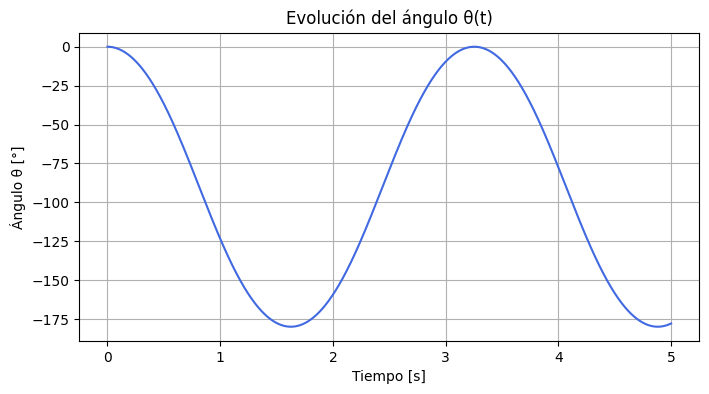

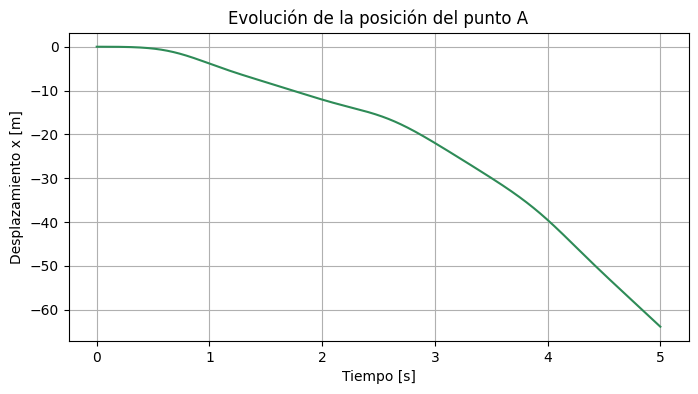

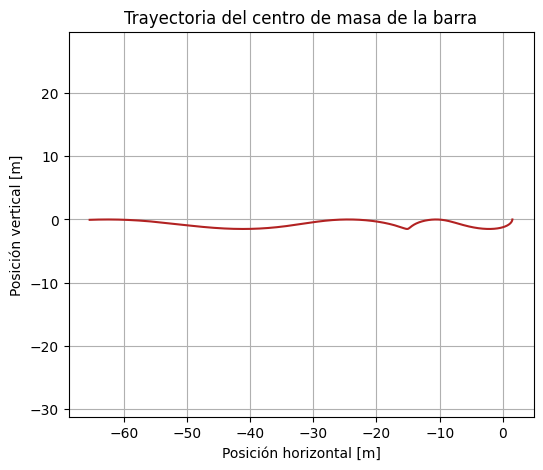

In [134]:
params = {m: 3, l: 2, beta: deg2rad(30), g: 9.81}

thetaddot_expr = sol[theta.diff(t, t)].subs(params).simplify()
xddot_expr = sol[x.diff(t, t)].subs(params).simplify()

thetaddot_fun = lambdify((theta, theta.diff(t), x, x.diff(t)), thetaddot_expr)
xddot_fun = lambdify((theta, theta.diff(t), x, x.diff(t)), xddot_expr)

def odefun(q, t):

    theta_val, thetadot_val, x_val, xdot_val = q
    
    thetaddot_val = thetaddot_fun(theta_val, thetadot_val, x_val, xdot_val)
    xddot_val = xddot_fun(theta_val, thetadot_val, x_val, xdot_val)
    
    return [thetadot_val, thetaddot_val, xdot_val, xddot_val]

ic = [0, 0, 0, 0]
tt = np.linspace(0, 5, 1000)
qq = sp.integrate.odeint(odefun, ic, tt)

# Gráfica 1: evolución del ángulo θ con el tiempo
plt.figure(figsize=(8,4))
plt.plot(tt, np.rad2deg(qq[:, 0]), color='royalblue')
plt.title("Evolución del ángulo θ(t)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Ángulo θ [°]")
plt.grid(True)
plt.show()

# Gráfica 2: evolución de la posición x del punto A con el tiempo
plt.figure(figsize=(8,4))
plt.plot(tt, qq[:, 2], color='seagreen')
plt.title("Evolución de la posición del punto A")
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento x [m]")
plt.grid(True)
plt.show()

xcm = qq[:, 2] + 0.75 * params[l] * np.cos(qq[:, 0])  # componente horizontal aproximada
ycm = 0.75 * params[l] * np.sin(qq[:, 0])             # componente vertical aproximada

plt.figure(figsize=(6,5))
plt.plot(xcm, ycm, color='firebrick')
plt.title("Trayectoria del centro de masa de la barra")
plt.xlabel("Posición horizontal [m]")
plt.ylabel("Posición vertical [m]")
plt.axis("equal")
plt.grid(True)
plt.show()
